
===== STICK MODEL RESULTS =====

Range -53.700 to -52.700 m
  Equivalent Drag Diameter  : 25.545 m
  Equivalent Inertia Diam.  : 8.271 m
  Force in Range            : 89355.43 N
  Moment about SWL          : -4753706.92 Nm

Range -52.700 to -27.386 m
  Equivalent Drag Diameter  : 25.545 m
  Equivalent Inertia Diam.  : 8.271 m
  Force in Range            : 2404830.86 N
  Moment about SWL          : -95409045.97 Nm

Range -27.386 to -7.173 m
  Equivalent Drag Diameter  : 25.545 m
  Equivalent Inertia Diam.  : 8.271 m
  Force in Range            : 2510033.55 N
  Moment about SWL          : -41951685.25 Nm

Range -7.173 to 8.967 m
  Equivalent Drag Diameter  : 25.545 m
  Equivalent Inertia Diam.  : 8.271 m
  Force in Range            : 397345.64 N
  Moment about SWL          : -2850160.25 Nm

Range 8.967 to 9.967 m
  Equivalent Drag Diameter  : 25.545 m
  Equivalent Inertia Diam.  : 8.271 m
  Force in Range            : 0.00 N
  Moment about SWL          : 0.00 Nm

Total Base Shear  : 540

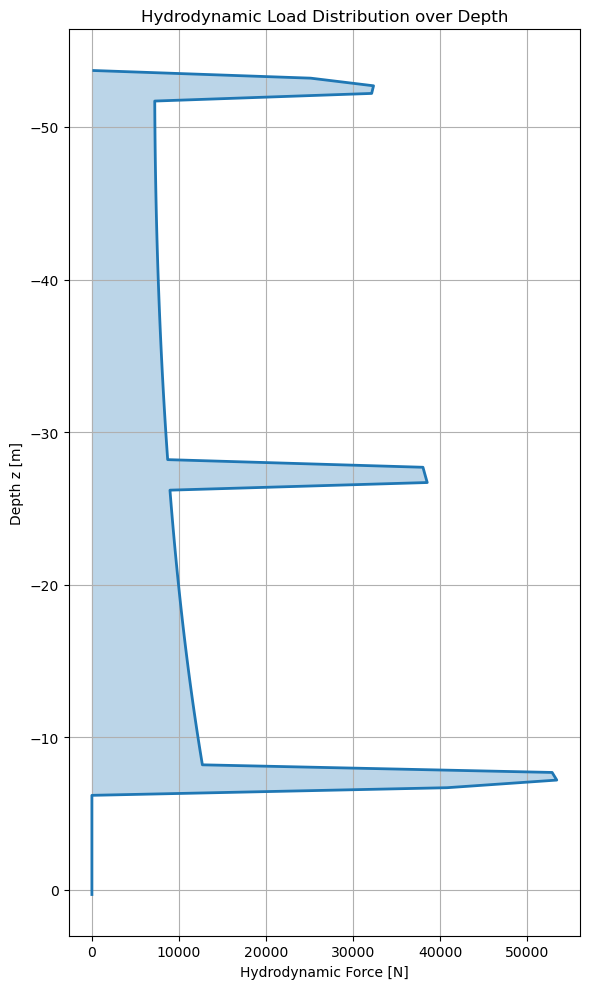

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# ------------------- INPUT SECTION -------------------
# =====================================================

H = 13.6          # wave height (m)
T = 15.0          # wave period (s)
h = 53.7          # water depth (m, SWL)
phase = np.pi/4

rho = 1025
CD = 1.0
CM = 2.0

# =====================================================
# ------- LOAD GEOMETRY FROM DESIGN PROJECT ----------
# =====================================================
# Run DesignProject.ipynb first so the %store cell executes,
# then these two variables are retrieved from the store.

%store -r nodes_3d       # {node_id: (x, y, z)}  — seabed z=0 convention
%store -r members_hydro  # [{'start': n1, 'end': n2, 'D': D_m}, ...]

nodes  = nodes_3d
members = members_hydro

# =====================================================
# ------------------- RANGES --------------------------
# =====================================================
# Auto-derived from unique Z elevations in the geometry (seabed z=0, SWL at z=h)
z_levels = sorted({round(v[2], 3) for v in nodes.values()})

ranges = [(z_levels[i] - h, z_levels[i+1] - h)
          for i in range(len(z_levels) - 1)
          if z_levels[i+1] <= h]  # only submerged ranges

# =====================================================
# ----------------- COMPUTATION PART -----------------
# =====================================================

g = 9.81

def wave_number(T, h):
    omega = 2*np.pi/T
    k = omega**2/g
    for _ in range(100):
        f  = g*k*np.tanh(k*h) - omega**2
        df = g*np.tanh(k*h) + g*k*h*(1/np.cosh(k*h))**2
        k -= f/df
    return k

def airy_kinematics(z, H, T, h, phase):
    omega = 2*np.pi/T
    k = wave_number(T, h)
    a = H/2
    u   = a*omega  *np.cosh(k*(z+h))/np.sinh(k*h)*np.cos(phase)
    a_x = a*omega**2*np.cosh(k*(z+h))/np.sinh(k*h)*np.sin(phase)
    return u, a_x

def wheeler_z(z, zeta, h):
    return ((z+h)/(h+zeta))*h - h

def stick_model():
    results = []
    for zL, zU in ranges:
        E0 = abs(zU - zL)
        Dde_sum = 0
        Die_sq_sum = 0

        for m in members:
            xi, yi, zi_raw = nodes[m['start']]
            xj, yj, zj_raw = nodes[m['end']]
            zi = zi_raw - h
            zj = zj_raw - h
            if max(zi, zj) > 0:
                continue
            D = m['D']
            dx, dy, dz = xj-xi, yj-yi, zj-zi
            L = np.sqrt(dx**2 + dy**2 + dz**2)
            if L == 0: continue
            p = np.sqrt(dx**2 + dy**2)
            q = (p*D)/L
            Dde_sum    += q
            Die_sq_sum += (q*D)**2

        Die_sum = np.sqrt(Die_sq_sum)
        z_pts = [zU, (zU+zL)/2, zL]
        f_vals = []
        for z in z_pts:
            if z > 0:
                f_vals.append(0.0)
                continue
            zeta = H/2*np.cos(phase)
            z_s  = wheeler_z(z, zeta, h)
            u, a_x = airy_kinematics(z_s, H, T, h, phase)
            f_vals.append(0.5*rho*CD*Dde_sum*u*abs(u)
                          + rho*CM*(np.pi/4)*Die_sum**2*a_x)

        FR = E0/6*(f_vals[0] + 4*f_vals[1] + f_vals[2])
        MR = E0/6*(f_vals[0]*zU + 4*f_vals[1]*((zU+zL)/2) + f_vals[2]*zL)
        results.append({'zU': zU, 'zL': zL, 'Force': FR, 'Moment_SWL': MR,
                        'Dde': Dde_sum, 'Die': Die_sum})

    F_total = sum(r['Force']      for r in results)
    M_total = sum(r['Moment_SWL'] for r in results)
    return F_total, M_total, results

def hydrodynamic_distribution(nodes, members, H, T, h, phase=phase, dz=0.5):
    z_min = min(z - h for _, _, z in nodes.values())
    z_grid = np.arange(z_min, dz, dz)
    distribution = []

    for z in z_grid:
        Dde_sum = 0
        Die_sq_sum = 0
        for m in members:
            xi, yi, zi_raw = nodes[m['start']]
            xj, yj, zj_raw = nodes[m['end']]
            zi = zi_raw - h
            zj = zj_raw - h
            if max(zi, zj) > 0:
                continue
            D = m['D']
            dx, dy, dz_m = xj-xi, yj-yi, zj-zi
            L = np.sqrt(dx**2 + dy**2 + dz_m**2)
            if L == 0: continue
            p = np.sqrt(dx**2 + dy**2)

            if abs(dz_m) < 1e-6 and abs(z - zi) <= D/2:
                q = (p*D)/L
            elif min(zi, zj) <= z <= max(zi, zj):
                q = (p*D)/L
            else:
                continue
            Dde_sum    += q
            Die_sq_sum += (q*D)**2

        Die_sum = np.sqrt(Die_sq_sum)
        zeta = H/2*np.cos(phase)
        z_s  = wheeler_z(z, zeta, h)
        u, a_x = airy_kinematics(z_s, H, T, h, phase)
        f_drag    = 0.5*rho*CD*Dde_sum*u*abs(u)
        f_inertia = rho*CM*(np.pi/4)*Die_sum**2*a_x
        distribution.append({'z': z, 'Force': f_drag + f_inertia})

    return distribution

# =====================================================
# ---------------------- OUTPUT -----------------------
# =====================================================

F_total, M_total, results = stick_model()

print("\n===== STICK MODEL RESULTS =====\n")
for r in results:
    print(f"Range {r['zU']:.3f} to {r['zL']:.3f} m")
    print(f"  Equivalent Drag Diameter  : {r['Dde']:.3f} m")
    print(f"  Equivalent Inertia Diam.  : {r['Die']:.3f} m")
    print(f"  Force in Range            : {r['Force']:.2f} N")
    print(f"  Moment about SWL          : {r['Moment_SWL']:.2f} Nm\n")
print("================================")
print(f"Total Base Shear  : {F_total:.2f} N")
print(f"Total Base Moment : {M_total:.2f} Nm")
print("================================\n")

force_distribution = hydrodynamic_distribution(nodes, members, H, T, h, phase=phase)

z_vals = [fd['z']     for fd in force_distribution]
forces  = [fd['Force'] for fd in force_distribution]

plt.figure(figsize=(6, 10))
plt.plot(forces, z_vals, linewidth=2)
plt.fill_betweenx(z_vals, 0, forces, alpha=0.3)
plt.axhline(0, color='blue', linewidth=1.2, linestyle='--', label='SWL')
plt.xlabel('Hydrodynamic Force per unit length [N/m]')
plt.ylabel('Elevation z [m]  (0 = SWL)')
plt.title('Hydrodynamic Load Distribution over Depth')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
